In [1]:
#Sentiment Analysis of Amazon product reviews using Python 

In [2]:
#Step 0: install dependent modules

In [2]:
#!pip install wordcloud

import pandas as pd
from wordcloud import WordCloud
import nltk

import matplotlib.pyplot as plt

In [4]:
#Step 1: Read the Dataframe: Reviews.csv file (Available for Download from the SentimentAnalysis folder under Resources on Google Drive)
#This dataset consists of reviews of fine foods from amazon. 
#The data span a period of more than 10 years, including all ~500,000 reviews up to October 2012.
#Reviews include product and user information, ratings, and a plain text review. 
#It also includes reviews from all other Amazon categories.

#Description of columns:
#Text — This variable contains the complete product review information.

#Summary — This is a summary of the entire review.

#Score — The product rating provided by the customer.

In [3]:
#Note: Change the file path here
df = pd.read_csv('C:\\Users\\karan\\Downloads\\archive\\Reviews_150.csv')
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
#Step 2: Generate a Word Cloud to see the most frequently occuring words after removing stopwords.
#stopwords: stopwords are words that are very common in human language but are generally not useful because they represent particularly common words such as “the”, “of”, and “to”.


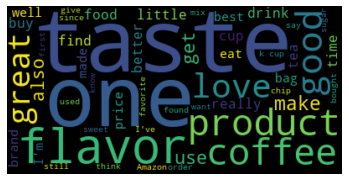

In [21]:

#nltk.download('stopwords')
from nltk.corpus import stopwords
# Create stopword list: stopwords 
stopwords = set(stopwords.words('english')) #TOPWORDS)
stopwords.update(["br", "href","and","the","of","like","much","would","wont","try","tried","even"])

# join the reviews
textt = " ".join(review for review in df.Text)

#generate a Word Cloud
wordcloud = WordCloud(stopwords=stopwords,max_words=50).generate(textt)


plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.savefig('wordcloud11.png')
plt.show()

In [ ]:
#Step 3: Use the NLTK module for sentiment analysis


In [26]:
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

#example:
sentiment_results=sia.polarity_scores("Wow, this is really easy!")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\karan\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [28]:
#Let's review the results from the sentiment analysis. Each text gets assigned 4 values each ranging from 0 (low) to 1 (high): 
#negative weight, neutral weight, positive weight, and compound weight which is the overall polarity score (higher value
#means a high positive polarity)
#neg: negative weight
#neu: neutral weight
#pos: positive weight
#compound: compound weight

#Our example text was classified to be 0% negative, 29.2% neutral, and 70.8% positive with an overall score of 80.1% being highly positive


In [27]:
print(sentiment_results)

{'neg': 0.0, 'neu': 0.292, 'pos': 0.708, 'compound': 0.8066}


In [ ]:
#Step 4: Apply the sentiment analysis function to the reviews
#1. Create a function called "is_positive" for classifying the text as positive (True or False) based on the compound score
#2. Use a for loop to apply the "is_positive" function for the first 10 reviews. You can change 10 to another number